<a href="https://colab.research.google.com/github/veerakumar17/veera-codeboosters-2026/blob/main/day4miniproject/day4miniproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

!pip install pyspark --quiet
print('PySpark installation complete!')
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year, month, to_date, col, round as spark_round

spark = SparkSession.builder \
  .appName('Day4_BigData_Sales') \
    .config('spark.sql.adaptive.enabled','true') \
      .getOrCreate()

print(f'Spark Version : {spark.version}')
print(f'SparkSession : ACTIVE')
print(f'Application : {spark.sparkContext.appName}')

PySpark installation complete!
Spark Version : 4.0.2
SparkSession : ACTIVE
Application : Day4_BigData_Sales


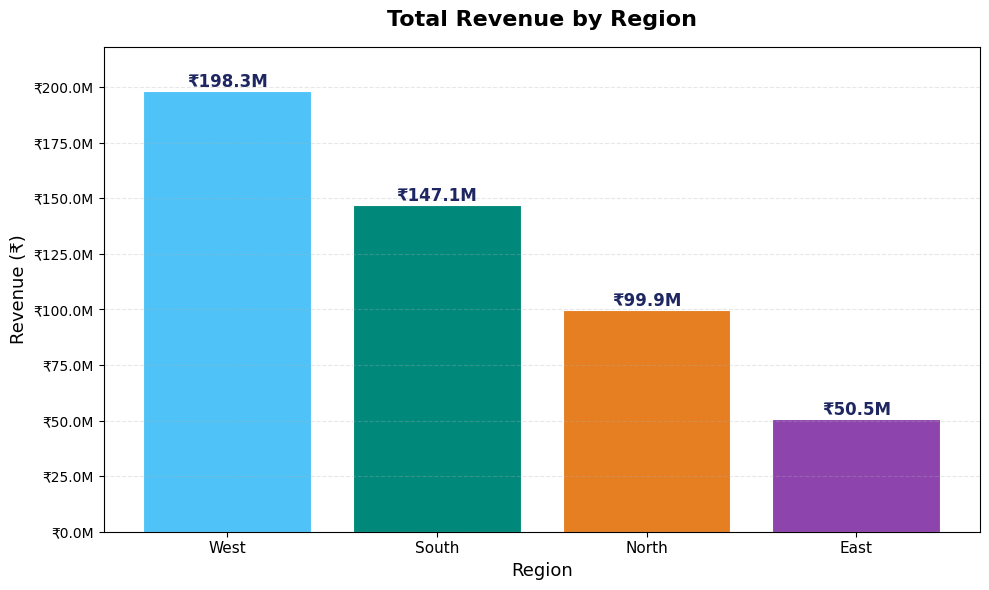

In [6]:
# Load data from the CSV file into a Spark DataFrame
sales_df = spark.read.csv('/content/large_sales_data.csv', header=True, inferSchema=True)
sales_df.createOrReplaceTempView("sales_data") # Register as a temporary SQL view

# Get data using Spark SQL
chart1_sql = """
SELECT region, ROUND(SUM(revenue), 2) AS total_revenue
FROM sales_data
GROUP BY region
ORDER BY total_revenue DESC
"""
chart1_data = spark.sql(chart1_sql).toPandas()


# Create the bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bar_color = ['#4FC3F7','#00897B','#E67E22','#8E44AD']

bars= ax.bar(
    chart1_data['region'],
    chart1_data['total_revenue'],
    color=bar_color,
    edgecolor='white',
    linewidth=0.8
)


for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f'₹{height/1000000:,.1f}M', # Format for better readability of revenue figures in Millions with Rupee symbol
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold',
        color ='#1E2761'
    )

ax.set_title('Total Revenue by Region', fontsize=16, fontweight='bold', pad = 15)
ax.set_xlabel('Region', fontsize = 13)
ax.set_ylabel('Revenue (₹)', fontsize = 13) # Changed Y-axis label to Amount
ax.set_ylim(0, chart1_data['total_revenue'].max() * 1.1) # Adjusted y-limit dynamically
ax.tick_params(axis='x', labelsize = 11)
ax.grid(axis='y', alpha = 0.3, linestyle ='--')

# Add Rupee symbol to Y-axis ticks
import matplotlib.ticker as mtick
formatter = mtick.FuncFormatter(lambda x, p: f'₹{x/1000000:,.1f}M') # Format ticks as ₹X.XM
ax.yaxis.set_major_formatter(formatter)


plt.tight_layout()
plt.show()